# SC-FC Coupling Cognitive State Classification using Multi-Layer Perceptron (MLP)

This notebook trains a custom Multi-Layer Perceptron (MLP) model to predict whether a subject is **NORMCOG** (Normal Cognition) or **DEMENTED** using brain SC-FC coupling vector data.

The workflow includes stratified train/validation/test splitting, Optuna hyperparameter optimization, final test evaluation, and a young-subject subgroup analysis.

## 1. Import Libraries

We begin by importing the required deep learning, data processing, and plotting packages.

In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    f1_score
)

from IPython import display

!pip install torchinfo
from torchinfo import summary

## 2. Reproducibility

A fixed random seed is used across Python, NumPy, PyTorch, the train/validation/test split, DataLoaders, and Optuna.

In [5]:
SEED = 34

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_torch_generator(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return g

set_seed(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 34


## 3. Configure Device

Configure GPU acceleration (`cuda`) if it is available; otherwise, fall back to CPU.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 4. Load and Preprocess Data

We load the SC-FC coupling features CSV file. Then, we encode the target variable (`NORMCOG` -> 0, `DEMENTED` -> 1) as class indices.

In [9]:
# Load the dataset using a relative path 
df = pd.read_csv("Myelin_FC_coupling_vectors.csv")
df_metadata = pd.read_csv("OASIS3_metadata_final.csv")

# Numerical dummy variable encoding: NORMCOG -> 0, DEMENTED -> 1
df['target'] = df['group'].map({'NORMCOG': 0, 'DEMENTED': 1})
df = df.dropna(subset=['target'])

# Define features dynamically by name (excluding Subject_ID, group, target, and Age)
id_col = 'Subject_ID'
target_col = 'target'
coupling_cols = [col for col in df.columns if col not in [id_col, 'group', target_col, 'Age']]

# Define class names for plotting/reporting
class_names = ['Normal', 'Demented']

print(f"Number of SC-FC coupling vector features: {len(coupling_cols)}")
print(f"Class counts:\n{df['group'].value_counts()}")

# Añadir la columna Age desde el metadata usando el subject ID
df = df.merge(
    df_metadata[['Subject_ID', 'Age']],
    left_on='Subject_ID',
    right_on='Subject_ID',
    how='left'
)
df = df.merge(
    df_metadata[['Subject_ID', 'Gender']],
    left_on='Subject_ID',
    right_on='Subject_ID',
    how='left'
)

Number of SC-FC coupling vector features: 7
Class counts:
group
NORMCOG     684
DEMENTED    399
Name: count, dtype: int64


In [10]:
df.head()

,Subject_ID,group,fc_myelin_coupling_Vis,fc_myelin_coupling_SomMot,fc_myelin_coupling_DorsAttn,fc_myelin_coupling_SalVentAttn,fc_myelin_coupling_Limbic,fc_myelin_coupling_Cont,fc_myelin_coupling_Default,target,Age,Gender
0,OAS30001,NORMCOG,0.173979,-0.022206,-0.000834,-0.026789,-0.006844,0.039038,0.011638,0,65.54,2
1,OAS30002,NORMCOG,0.054960,-0.109930,-0.049039,-0.121121,-0.037282,-0.141439,-0.047350,0,69.04,1
2,OAS30003,NORMCOG,0.192220,-0.037714,-0.062666,-0.049135,0.047912,0.006713,0.002891,0,60.34,2
3,OAS30004,NORMCOG,0.125525,0.172956,0.102253,0.024435,0.005592,0.067687,0.022383,0,58.14,2
4,OAS30005,NORMCOG,0.071141,0.169766,0.079471,0.077136,0.009362,0.115633,0.103226,0,49.65,2


## 5. Stratified Three-Way Dataset Splitting

We split the dataset into 60% Training, 20% Validation, and 20% Testing. Features are scaled using a standard scaler fitted only on the training set to prevent data leakage.

In [12]:
# Stratify by label + age bin + gender to ensure balanced distributions:
df["age_bin"] = (df["Age"] >= 75).astype(int)
df["strat"]   = (
    df["target"].astype(str) + "_" +
    df["age_bin"].astype(str) + "_" +
    df["Gender"].astype(str)   # 1 = male, 2 = female
)

print("Stratum distribution:\n", df["strat"].value_counts())

test_val_df, train_df = train_test_split(
    df, test_size=0.6, stratify=df["strat"], random_state=SEED
)
test_df, val_df = train_test_split(
    test_val_df, test_size=0.5, stratify=test_val_df["strat"], random_state=SEED
)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n── {name} ──")
    print(split["target"].value_counts(normalize=True).rename({0: "Normal", 1: "Demented"}))
    print(f"Age mean : {split['Age'].mean():.1f}  std: {split['Age'].std():.1f}")
    print(f"Gender   : {split['Gender'].value_counts(normalize=True).rename({1: 'Male', 2: 'Female'}).to_dict()}")

print(f"Split sizes - Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Scale SC-FC coupling vectors based on training data statistics
coupling_scaler = StandardScaler()
X_train_coupling = coupling_scaler.fit_transform(train_df[coupling_cols])
X_val_coupling = coupling_scaler.transform(val_df[coupling_cols])
X_test_coupling = coupling_scaler.transform(test_df[coupling_cols])

y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

Stratum distribution:
 strat
0_0_2    341
0_0_1    235
1_1_1    118
1_1_2    108
1_0_1     92
1_0_2     81
0_1_2     63
0_1_1     45
Name: count, dtype: int64

Train: 650  |  Val: 217  |  Test: 216
Total: 1083

── Train ──
target
Normal      0.632308
Demented    0.367692
Name: proportion, dtype: float64
Age mean : 70.3  std: 9.5
Gender   : {'Female': 0.5476923076923077, 'Male': 0.4523076923076923}

── Val ──
target
Normal      0.626728
Demented    0.373272
Name: proportion, dtype: float64
Age mean : 70.4  std: 8.5
Gender   : {'Female': 0.543778801843318, 'Male': 0.45622119815668205}

── Test ──
target
Normal      0.634259
Demented    0.365741
Name: proportion, dtype: float64
Age mean : 71.2  std: 9.1
Gender   : {'Female': 0.5509259259259259, 'Male': 0.44907407407407407}
Split sizes - Train: 650 | Val: 217 | Test: 216


## 6. PyTorch Datasets and Dataloaders

We create a custom PyTorch Dataset class to manage batch delivery. We reshape the SC-FC coupling vector to `(1, num_features)` to represent a single input channel.

In [14]:
class CouplingDataset(Dataset):
    def __init__(self, myelin_features, targets):
        self.myelin = torch.tensor(myelin_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.long)
        
    def __len__(self):
        return len(self.targets)
        
    def __getitem__(self, idx):
        # Reshape to (1, num_features) to represent 1 channel for 1D convolutions
        myelin_tensor = self.myelin[idx].unsqueeze(0)
        return myelin_tensor, self.targets[idx]

batch_size = 16
train_dataset = CouplingDataset(X_train_coupling, y_train)
val_dataset = CouplingDataset(X_val_coupling, y_val)
test_dataset = CouplingDataset(X_test_coupling, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=make_torch_generator(SEED)
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 41


## 7. Model Architecture

We design our Multi-Layer Perceptron (MLP) Neural Network model, which flattens the input vector and passes it through fully connected layers with Batch Normalization, ReLUs, and Dropout.

In [16]:
class CouplingMLP(nn.Module):
    def __init__(self, input_dim, config=None, num_classes=2):
        super(CouplingMLP, self).__init__()

        if config is None:
            config = {
                "n_fc_layers": 2,
                "fc_units": 256,
                "dropout": 0.3
            }

        n_fc_layers = config["n_fc_layers"]
        fc_units = config["fc_units"]
        dropout = config["dropout"]

        layers = []
        in_features = input_dim

        # Hidden fully connected layers optimized by Optuna
        for _ in range(n_fc_layers):
            layers += [
                nn.Linear(in_features, fc_units),
                nn.BatchNorm1d(fc_units),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ]
            in_features = fc_units

        # Final classification layer
        layers.append(nn.Linear(in_features, num_classes))

        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten input from (batch_size, 1, input_dim) to (batch_size, input_dim)
        if x.dim() > 2:
            x = torch.flatten(x, 1)
        return self.fc(x)

# Example model used only to inspect the architecture
example_config = {
    "n_fc_layers": 2,
    "fc_units": 256,
    "dropout": 0.3
}

model = CouplingMLP(input_dim=len(coupling_cols), config=example_config).to(device)
summary(model, input_size=(32, 1, len(coupling_cols)))


Layer (type:depth-idx)                   Output Shape              Param #
CouplingMLP                              [32, 2]                   --
├─Sequential: 1-1                        [32, 2]                   --
│    └─Linear: 2-1                       [32, 256]                 2,048
│    └─BatchNorm1d: 2-2                  [32, 256]                 512
│    └─ReLU: 2-3                         [32, 256]                 --
│    └─Dropout: 2-4                      [32, 256]                 --
│    └─Linear: 2-5                       [32, 256]                 65,792
│    └─BatchNorm1d: 2-6                  [32, 256]                 512
│    └─ReLU: 2-7                         [32, 256]                 --
│    └─Dropout: 2-8                      [32, 256]                 --
│    └─Linear: 2-9                       [32, 2]                   514
Total params: 69,378
Trainable params: 69,378
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.22
Input size (MB): 0.00
Forward/backw

## 8. Model Training Setup

We write a training function with early stopping, saving the best weights whenever validation **F1-macro** improves.

In [18]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=50, epoch_details=True):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0.0
    patience_counter = 0
    early_stop_patience = 10
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        train_preds, train_labels = [], []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
            
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
                
        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100 * train_correct / train_total
        epoch_val_acc = 100 * val_correct / val_total
        epoch_train_f1 = f1_score(train_labels, train_preds, average='macro')
        epoch_val_f1 = f1_score(val_labels, val_preds, average='macro')
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['train_f1'].append(epoch_train_f1)
        history['val_f1'].append(epoch_val_f1)
        
        if epoch_details:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% F1: {epoch_train_f1:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}% F1: {epoch_val_f1:.4f}")
            
        scheduler.step(epoch_val_loss)
        
        # Early stopping & model saving based on maximizing F1-macro score
        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_sc_fc.pth')
            if epoch_details:
                print(f"SAVED model so far) (Best Val F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                if epoch_details:
                    print("EARLY STOPPING...")
                break
                
    model.load_state_dict(torch.load('best_model_sc_fc.pth'))
    return history

## 9. Initial MLP Training

Train the model for 50 epochs using early stopping (maximizing validation F1-macro) and standard optimizer settings.

In [20]:
epochs = 50
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss()

history = train_model(model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=device, epochs=epochs)

Epoch 1/50: Train Loss: 0.6317 Acc: 68.77% F1: 0.6485 | Val Loss: 0.5882 Acc: 70.97% F1: 0.6760
SAVED model so far) (Best Val F1: 0.6760)
Epoch 2/50: Train Loss: 0.5481 Acc: 71.69% F1: 0.6934 | Val Loss: 0.5588 Acc: 72.81% F1: 0.7004
SAVED model so far) (Best Val F1: 0.7004)
Epoch 3/50: Train Loss: 0.5576 Acc: 72.77% F1: 0.6983 | Val Loss: 0.5691 Acc: 70.97% F1: 0.6820
Epoch 4/50: Train Loss: 0.5615 Acc: 72.00% F1: 0.6914 | Val Loss: 0.5567 Acc: 70.51% F1: 0.6573
Epoch 5/50: Train Loss: 0.5622 Acc: 70.62% F1: 0.6685 | Val Loss: 0.5616 Acc: 73.73% F1: 0.6910
Epoch 6/50: Train Loss: 0.5619 Acc: 73.23% F1: 0.7004 | Val Loss: 0.5611 Acc: 71.43% F1: 0.6778
Epoch 7/50: Train Loss: 0.5425 Acc: 72.92% F1: 0.6935 | Val Loss: 0.5678 Acc: 70.97% F1: 0.6873
Epoch 8/50: Train Loss: 0.5348 Acc: 73.69% F1: 0.7059 | Val Loss: 0.5622 Acc: 72.35% F1: 0.6860
Epoch 9/50: Train Loss: 0.5033 Acc: 74.31% F1: 0.7204 | Val Loss: 0.5622 Acc: 70.51% F1: 0.6832
Epoch 10/50: Train Loss: 0.5191 Acc: 74.92% F1: 0.73

## 10. Plot Loss & Accuracy Curves

We visualize training and validation loss and accuracy over epochs.

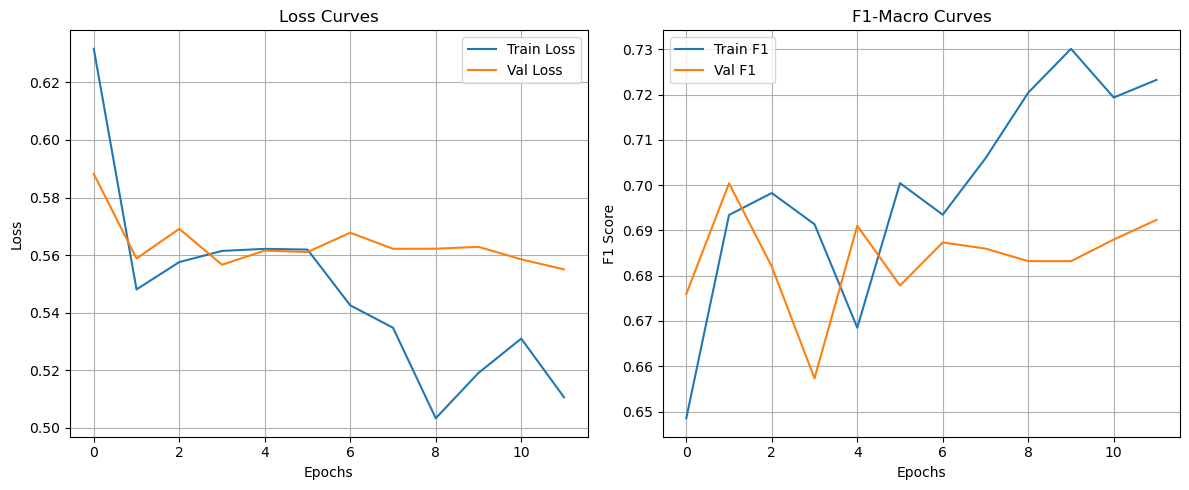

In [22]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_f1'], label='Train F1')
plt.plot(history['val_f1'], label='Val F1')
plt.title('F1-Macro Curves')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning with Optuna (MLP)

We systematically search for the best combination of hyperparameters using Bayesian Optimization (Optuna), maximizing the validation **F1-macro** score.

In [24]:
# Install Optuna if not already installed
!pip install optuna
import optuna

EPOCHS_OPTUNA = 50
N_TRIALS = 30
WEIGHT_DECAY = 1e-4


def objective(trial):
    set_seed(SEED + trial.number)

    # 1. Suggest hyperparameters using the generalized Optuna search space
    n_fc_layers = trial.suggest_int("n_fc_layers", 0, 3)
    fc_units = trial.suggest_int("fc_units", 64, 512, step=64)
    dropout = trial.suggest_float("dropout", 0.1, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    config = {
        "n_fc_layers": n_fc_layers,
        "fc_units": fc_units,
        "dropout": dropout
    }

    # 2. Rebuild loaders
    trainloader_conf = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=make_torch_generator(SEED + trial.number)
    )
    valloader_conf = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 3. Create model, optimizer, scheduler, criterion
    model_conf = CouplingMLP(
        input_dim=len(coupling_cols),
        config=config,
        num_classes=2
    ).to(device)

    optimizer_conf = optim.Adam(
        model_conf.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    scheduler_conf = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_conf,
        mode="min",
        factor=0.1,
        patience=3
    )

    criterion = nn.CrossEntropyLoss()

    # 4. Training loop with Optuna pruning
    best_val_f1 = 0.0

    for epoch in range(EPOCHS_OPTUNA):
        model_conf.train()

        for inputs, labels in trainloader_conf:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer_conf.zero_grad()
            outputs = model_conf(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_conf.step()

        model_conf.eval()
        val_preds, val_labels = [], []
        val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in valloader_conf:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_conf(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)

                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(valloader_conf)
        epoch_val_f1 = f1_score(val_labels, val_preds, average="macro", zero_division=0)

        scheduler_conf.step(epoch_val_loss)

        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1

        # Report intermediate value for pruning
        trial.report(epoch_val_f1, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_f1


In [25]:
# Run Optuna Study maximizing F1-macro score
optuna.logging.set_verbosity(optuna.logging.INFO)

sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, timeout=600)

print("OPTUNA STUDY COMPLETE")
print(f"Best Trial F1-Macro: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-06-10 23:55:03,065] A new study created in memory with name: no-name-c7958e13-469d-4799-bae9-61f4fef8939e
[I 2026-06-10 23:55:04,862] Trial 0 finished with value: 0.6882183908045978 and parameters: {'n_fc_layers': 0, 'fc_units': 448, 'dropout': 0.14635187766706667, 'batch_size': 32, 'lr': 0.0007130972530218766}. Best is trial 0 with value: 0.6882183908045978.
[I 2026-06-10 23:55:07,241] Trial 1 finished with value: 0.7048323589070516 and parameters: {'n_fc_layers': 1, 'fc_units': 128, 'dropout': 0.30741231646838574, 'batch_size': 32, 'lr': 0.0016522334368670433}. Best is trial 1 with value: 0.7048323589070516.
[I 2026-06-10 23:55:19,112] Trial 2 finished with value: 0.7073368099262722 and parameters: {'n_fc_layers': 3, 'fc_units': 448, 'dropout': 0.23584166686915073, 'batch_size': 8, 'lr': 0.002688069837898252}. Best is trial 2 with value: 0.7073368099262722.
[I 2026-06-10 23:55:26,636] Trial 3 finished with value: 0.6961607949412827 and parameters: {'n_fc_layers': 1, 'fc_units

OPTUNA STUDY COMPLETE
Best Trial F1-Macro: 0.7182
Best Parameters: {'n_fc_layers': 1, 'fc_units': 256, 'dropout': 0.18701218551089518, 'batch_size': 8, 'lr': 0.00477314175922415}


In [26]:
# Print study trials summary
study_df = study.trials_dataframe()

cols_to_show = [
    "number",
    "value",
    "params_n_fc_layers",
    "params_fc_units",
    "params_dropout",
    "params_batch_size",
    "params_lr",
    "state"
]

print("OPTUNA STUDY SUMMARY (SORTED BY VAL F1)")
print(
    study_df
    .sort_values(by="value", ascending=False)[cols_to_show]
    .head(10)
    .to_string(index=False)
)


OPTUNA STUDY SUMMARY (SORTED BY VAL F1)
 number    value  params_n_fc_layers  params_fc_units  params_dropout  params_batch_size  params_lr    state
      9 0.718182                   1              256        0.187012                  8   0.004773 COMPLETE
      4 0.707688                   1              128        0.187347                 32   0.004698 COMPLETE
      2 0.707337                   3              448        0.235842                  8   0.002688 COMPLETE
      1 0.704832                   1              128        0.307412                 32   0.001652 COMPLETE
      3 0.696161                   1              320        0.292788                  8   0.000206 COMPLETE
      0 0.688218                   0              448        0.146352                 32   0.000713 COMPLETE
     21 0.674959                   3              512        0.241813                  8   0.002321   PRUNED
     22 0.673933                   3              512        0.208904                  8

## 12. Final Model Retraining & Test Evaluation (MLP)

We retrain the model using the best hyperparameters selected by Optuna and evaluate its final classification performance on the independent test set.


In [28]:
# Identify best configuration from Optuna
best_params = study.best_params
print("Best parameters:")
print(best_params)

best_batch_size = int(best_params["batch_size"])
best_lr = float(best_params["lr"])

final_config = {
    "n_fc_layers": int(best_params["n_fc_layers"]),
    "fc_units": int(best_params["fc_units"]),
    "dropout": float(best_params["dropout"])
}

print("\nFinal model configuration:")
print(final_config)

if final_config["n_fc_layers"] == 0:
    print("\nNote: n_fc_layers = 0, so fc_units is not used in the final architecture.")

# 1. Rebuild loaders with best batch size
train_loader_best = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=make_torch_generator(SEED)
)
val_loader_best = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False)
test_loader_best = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

set_seed(SEED)

# 2. Re-instantiate model, optimizer, scheduler, criterion
model_best = CouplingMLP(
    input_dim=len(coupling_cols),
    config=final_config,
    num_classes=2
).to(device)

optimizer_best = optim.Adam(
    model_best.parameters(),
    lr=best_lr,
    weight_decay=WEIGHT_DECAY
)

scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_best,
    mode="min",
    factor=0.1,
    patience=3
)

criterion_best = nn.CrossEntropyLoss()

# 3. Retrain model
print("\nRetraining model with best hyperparameters...")
history_best = train_model(
    model=model_best,
    train_loader=train_loader_best,
    val_loader=val_loader_best,
    criterion=criterion_best,
    optimizer=optimizer_best,
    scheduler=scheduler_best,
    device=device,
    epochs=50,
    epoch_details=True
)

# 4. Generate predictions on test set
model_best.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader_best:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_best(inputs)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# 5. Compute test metrics
mlp_test_accuracy = accuracy_score(all_labels, all_preds)
mlp_test_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"\nMLP Test Accuracy: {mlp_test_accuracy * 100:.2f}%")
print(f"MLP Test F1-Macro: {mlp_test_f1:.4f}")
print("\nMLP Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


Best parameters:
{'n_fc_layers': 1, 'fc_units': 256, 'dropout': 0.18701218551089518, 'batch_size': 8, 'lr': 0.00477314175922415}

Final model configuration:
{'n_fc_layers': 1, 'fc_units': 256, 'dropout': 0.18701218551089518}

Retraining model with best hyperparameters...
Epoch 1/50: Train Loss: 0.6610 Acc: 66.62% F1: 0.6360 | Val Loss: 0.5956 Acc: 69.59% F1: 0.6781
SAVED model so far) (Best Val F1: 0.6781)
Epoch 2/50: Train Loss: 0.5978 Acc: 68.77% F1: 0.6539 | Val Loss: 0.6742 Acc: 70.51% F1: 0.5842
Epoch 3/50: Train Loss: 0.5981 Acc: 69.85% F1: 0.6570 | Val Loss: 0.6650 Acc: 68.20% F1: 0.6740
Epoch 4/50: Train Loss: 0.6227 Acc: 69.23% F1: 0.6572 | Val Loss: 0.5883 Acc: 70.05% F1: 0.6757
Epoch 5/50: Train Loss: 0.6044 Acc: 69.54% F1: 0.6500 | Val Loss: 0.6003 Acc: 69.59% F1: 0.6822
SAVED model so far) (Best Val F1: 0.6822)
Epoch 6/50: Train Loss: 0.6347 Acc: 70.00% F1: 0.6716 | Val Loss: 0.6117 Acc: 64.52% F1: 0.5283
Epoch 7/50: Train Loss: 0.5687 Acc: 70.00% F1: 0.6608 | Val Loss: 0.

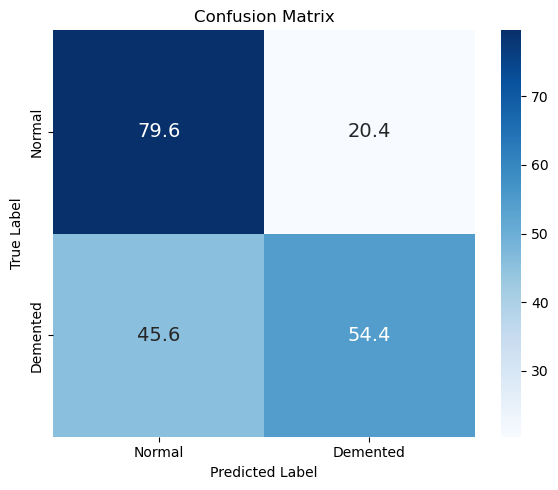

In [29]:
# MLP confusion matrix in percentages
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14}
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 13. Young Subject Subgroup Analysis

The independent test set is filtered to include only subjects younger than 75 years, and the final MLP model is evaluated on this subgroup.

Young test subset: Age < 75
Number of subjects: 150
Class distribution:
target
NORMCOG     115
DEMENTED     35
Name: count, dtype: int64
Class distribution (%):
target
NORMCOG     76.666667
DEMENTED    23.333333
Name: proportion, dtype: float64
Age mean : 66.7
Age std  : 6.6
Age range: 43.5 - 74.9
--- MLP: YOUNG TEST SUBSET ---
Accuracy : 74.00%
F1-Macro : 0.6082
Classification Report:
              precision    recall  f1-score   support

      Normal     0.8115    0.8609    0.8354       115
    Demented     0.4286    0.3429    0.3810        35

    accuracy                         0.7400       150
   macro avg     0.6200    0.6019    0.6082       150
weighted avg     0.7221    0.7400    0.7294       150



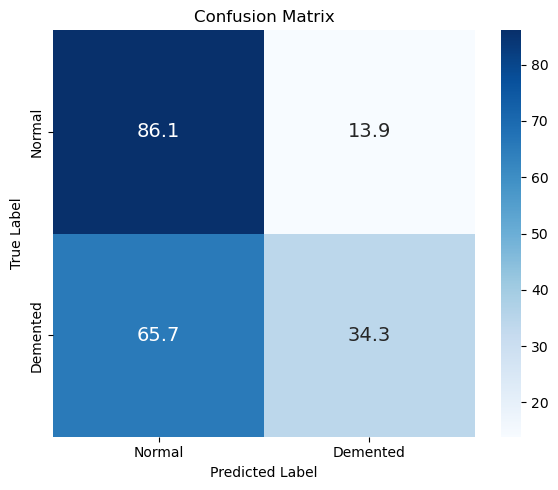

=== FULL TEST SET VS YOUNG TEST SUBSET ===
MLP: Full F1 = 0.6732 | Young F1 = 0.6082
MLP: Full Accuracy = 70.37% | Young Accuracy = 74.00%


In [31]:
# =========================================================
# Young Subject Subgroup Analysis: Age < 75 years
# =========================================================

AGE_THRESHOLD = 75

young_test_df = test_df[test_df["Age"] < AGE_THRESHOLD].copy()

print("=" * 60)
print(f"Young test subset: Age < {AGE_THRESHOLD}")
print("=" * 60)
print(f"Number of subjects: {len(young_test_df)}")

print("Class distribution:")
print(young_test_df[target_col].value_counts().rename({0: "NORMCOG", 1: "DEMENTED"}))

print("Class distribution (%):")
print((young_test_df[target_col].value_counts(normalize=True) * 100).rename({0: "NORMCOG", 1: "DEMENTED"}))

print(f"Age mean : {young_test_df['Age'].mean():.1f}")
print(f"Age std  : {young_test_df['Age'].std():.1f}")
print(f"Age range: {young_test_df['Age'].min():.1f} - {young_test_df['Age'].max():.1f}")

# Scale young test features using the scaler fitted only on the training set
X_young_test_coupling = coupling_scaler.transform(young_test_df[coupling_cols])
y_young_test = young_test_df[target_col].values

young_test_dataset = CouplingDataset(X_young_test_coupling, y_young_test)
young_test_loader = DataLoader(
    young_test_dataset,
    batch_size=best_batch_size,
    shuffle=False
)

# ---------------------------------------------------------
# MLP predictions on young test subset
# ---------------------------------------------------------
model_best.eval()
young_mlp_preds = []
young_mlp_labels = []
young_mlp_probs = []

with torch.no_grad():
    for inputs, labels in young_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_best(inputs)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs.data, 1)

        young_mlp_preds.extend(predicted.cpu().numpy())
        young_mlp_labels.extend(labels.cpu().numpy())
        young_mlp_probs.extend(probs.cpu().numpy())

young_mlp_preds = np.array(young_mlp_preds)
young_mlp_labels = np.array(young_mlp_labels)
young_mlp_probs = np.array(young_mlp_probs)

young_mlp_acc = accuracy_score(young_mlp_labels, young_mlp_preds)
young_mlp_f1 = f1_score(young_mlp_labels, young_mlp_preds, average="macro", zero_division=0)

print("--- MLP: YOUNG TEST SUBSET ---")
print(f"Accuracy : {young_mlp_acc * 100:.2f}%")
print(f"F1-Macro : {young_mlp_f1:.4f}")
print("Classification Report:")
print(classification_report(young_mlp_labels, young_mlp_preds, target_names=class_names, digits=4, zero_division=0))

cm_young_mlp = confusion_matrix(young_mlp_labels, young_mlp_preds, labels=[0, 1])
cm_young_mlp_percent = cm_young_mlp.astype("float") / cm_young_mlp.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_young_mlp_percent,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 14}
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Final comparison between complete test set and young subgroup
print("=== FULL TEST SET VS YOUNG TEST SUBSET ===")
print(f"MLP: Full F1 = {mlp_test_f1:.4f} | Young F1 = {young_mlp_f1:.4f}")
print(f"MLP: Full Accuracy = {mlp_test_accuracy * 100:.2f}% | Young Accuracy = {young_mlp_acc * 100:.2f}%")